In [1]:
# Cell 1 — Setup
%matplotlib inline
import warnings
warnings.filterwarnings("ignore", message="pandas only supports SQLAlchemy")
import time
import json
import re
import ssl
from urllib.request import Request, urlopen
from urllib.parse import urlencode
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import geopandas as gpd
import pyogrio
from IPython.display import Image as IPImage

from scripts.shared import db_utils
from app.db.signature import get_elevation_point  # single-point production helper (small-N fallback only)

conn = db_utils.db_connect()
ROOT = Path(db_utils.__file__).parent.parent.parent
OUT  = ROOT / 'output' / 'cdop'
OUT.mkdir(parents=True, exist_ok=True)
DPLACE_CLDF = ROOT / 'data' / 'dplace' / 'cldf'

WORLD = gpd.read_file(Path(pyogrio.__file__).parent / 'tests/fixtures/naturalearth_lowres/naturalearth_lowres.shp')

# Harmonic constants (WO2a/WO3 continuous precip representation; temp annual harmonic)
month_cols = [f'pre_mm_s{i:02d}' for i in range(1, 13)]
temp_cols  = [f'tmp_dc_s{i:02d}' for i in range(1, 13)]
months     = np.arange(12)
theta1     = 2 * np.pi * months / 12
theta2     = 2 * np.pi * months / 6

LAPSE_RATE_C_PER_KM = 6.5  # standard environmental lapse rate
EARTH_R_KM = 6371.0

def haversine_km(lat1, lon1, lat2, lon2):
    """Vectorized great-circle distance in km. Args may be scalars or numpy arrays."""
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat / 2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2)**2
    return 2 * EARTH_R_KM * np.arcsin(np.sqrt(a))

print("Setup complete.")

Setup complete.


In [2]:
# Cell 2 — Batched elevation lookup (bulk; notebook-local, not production)
# get_elevation_point() (app/db/signature.py) is single-point with a 512-entry cache, built for
# interactive per-query use. This is a bulk-only helper for the ~1,500-point corpus in Part 0B.
import warnings; warnings.filterwarnings("ignore", message="pandas only supports SQLAlchemy")

try:
    import certifi
    _SSL_CTX = ssl.create_default_context(cafile=certifi.where())
except ImportError:
    _SSL_CTX = ssl.create_default_context()

def _http_get_json(url, timeout_s=10.0):
    req = Request(url, headers={"Accept": "application/json", "User-Agent": "edop-cdop-wo4/0.1"})
    with urlopen(req, timeout=timeout_s, context=_SSL_CTX) as resp:
        return json.loads(resp.read().decode("utf-8"))

def get_elevations_batch(coords, chunk_size=100, sleep_s=1.1):
    """coords: list of (lat, lon). Returns list of elevation floats (NaN on failure).
    OpenTopoData /mapzen supports up to 100 locations/request; public rate limit ~1 req/sec.
    """
    out = [np.nan] * len(coords)
    n_chunks = (len(coords) + chunk_size - 1) // chunk_size
    for c in range(n_chunks):
        chunk = coords[c*chunk_size:(c+1)*chunk_size]
        locs = "|".join(f"{lat},{lon}" for lat, lon in chunk)
        url = f"https://api.opentopodata.org/v1/mapzen?{urlencode({'locations': locs})}"
        try:
            payload = _http_get_json(url)
            results = payload.get("results", [])
            for i, r in enumerate(results):
                elev = r.get("elevation")
                if elev is not None:
                    out[c*chunk_size + i] = float(elev)
        except Exception as e:
            print(f"  batch {c+1}/{n_chunks} failed ({e}); stragglers retried individually below")
        print(f"  batch {c+1}/{n_chunks} done")
        time.sleep(sleep_s)

    n_missing = sum(1 for v in out if np.isnan(v))
    if n_missing:
        print(f"  {n_missing} points missing after batch pass; retrying individually via get_elevation_point()")
        for i, (lat, lon) in enumerate(coords):
            if np.isnan(out[i]):
                val = get_elevation_point(lat, lon)
                if val.get('elev_point') is not None:
                    out[i] = val['elev_point']
    return out

print("Elevation batching helper ready.")

Elevation batching helper ready.


## Probes

Six named probes from the WO, plus **Santiago** (Southern Hemisphere — the retired phase
lens never resolved hemisphere behaviour; the WO's own proviso suggests adding one).

**Lens (corrected 2026-07-21):** production `climate.precip` exactly — 5 features
(`log_pre_mm_syr, a1, b1, a2, b2`), euclidean distance on z-scored variables, per
`app/db/seasonality.py` (the WO text names `app/db/similarity.py`, which doesn't exist).
An earlier pass here used only the 4 shape features `(a1,b1,a2,b2)` with raw, unstandardized
Euclidean distance — silently dropping magnitude from the comparison and letting a
larger-variance dimension dominate. That produced spurious near-antipodal "matches" for
George Town before the fix (caught via Part 1's place names — see that section).
`climate.temp` (a genuinely different feature set, `tmp_dc_syr, tmp_seas_amp,
tmp_concentration`, Mahalanobis) as secondary, most informative for Tbilisi.

**Scoping decision (not fixed by the WO text, made here for tractability):** Parts 1–2
(analogue search) run at **L08 only** — matches the direction CDOP's own similarity index
already took (WO1), and is the more representative level per-probe. Part 4 uses **L06**,
matching the WO's own text ("percentile against the full L06 population"). Part 0's container
comparison is the one place both levels are shown side by side — that's the whole point of it.

In [3]:
# Cell 4 — Probe definitions
PROBES = [
    ('Mombasa',      -4.0435,   39.6682),
    ('Augsburg',     48.3705,   10.8978),
    ('Tbilisi',      41.6938,   44.8015),
    ('Kaifeng',      34.7986,  114.3413),
    ('Timbuktu',     16.8167,   -2.9833),
    ('George Town',   5.4141,  100.3288),
    ('Santiago',    -33.4489,  -70.6693),
]
probe_df = pd.DataFrame(PROBES, columns=['probe', 'lat', 'lon'])
print(probe_df.to_string(index=False))

      probe      lat      lon
    Mombasa  -4.0435  39.6682
   Augsburg  48.3705  10.8978
    Tbilisi  41.6938  44.8015
    Kaifeng  34.7986 114.3413
   Timbuktu  16.8167  -2.9833
George Town   5.4141 100.3288
   Santiago -33.4489 -70.6693


In [4]:
# Cell 5 — Resolve each probe's containing basin at L06 and L08
import warnings; warnings.filterwarnings("ignore", message="pandas only supports SQLAlchemy")

BASIN_COLS = """hybas_id, ele_mt_sav, ele_mt_smn, ele_mt_smx,
       pre_mm_s01, pre_mm_s02, pre_mm_s03, pre_mm_s04, pre_mm_s05, pre_mm_s06,
       pre_mm_s07, pre_mm_s08, pre_mm_s09, pre_mm_s10, pre_mm_s11, pre_mm_s12,
       tmp_dc_s01, tmp_dc_s02, tmp_dc_s03, tmp_dc_s04, tmp_dc_s05, tmp_dc_s06,
       tmp_dc_s07, tmp_dc_s08, tmp_dc_s09, tmp_dc_s10, tmp_dc_s11, tmp_dc_s12"""

def resolve_basin(level, lat, lon):
    table = 'basin06' if level == 6 else 'basin08'
    sql = f"""
    SELECT {BASIN_COLS}
    FROM {table}
    WHERE ST_Within(ST_SetSRID(ST_MakePoint({lon}, {lat}), 4326), geom)
    ORDER BY ST_Area(geom::geography) ASC LIMIT 1
    """
    row = pd.read_sql(sql, conn)
    return None if row.empty else row.iloc[0]

rows = []
for name, lat, lon in PROBES:
    for level in (6, 8):
        r = resolve_basin(level, lat, lon)
        if r is None:
            print(f"  WARNING: no basin found for {name} at L{level}")
            continue
        d = r.to_dict()
        d['probe'] = name; d['lat'] = lat; d['lon'] = lon; d['level'] = level
        rows.append(d)

probe_basins = pd.DataFrame(rows)
print(f"Resolved {len(probe_basins)} probe x level rows")

Resolved 14 probe x level rows


In [5]:
# Cell 6 — Harmonic features for probe basins (WO2a/WO3 continuous representation)
import warnings; warnings.filterwarnings("ignore", message="pandas only supports SQLAlchemy")

def add_harmonic_features(df):
    P = df[month_cols].values.astype(float)
    t = P.sum(axis=1)
    with np.errstate(invalid='ignore', divide='ignore'):
        df['a1'] = np.where(t > 0, (P * np.cos(theta1)).sum(axis=1) / t, np.nan)
        df['b1'] = np.where(t > 0, (P * np.sin(theta1)).sum(axis=1) / t, np.nan)
        df['a2'] = np.where(t > 0, (P * np.cos(theta2)).sum(axis=1) / t, np.nan)
        df['b2'] = np.where(t > 0, (P * np.sin(theta2)).sum(axis=1) / t, np.nan)
    df['pre_mm_syr'] = t
    df['log_pre_mm_syr'] = np.log1p(t)  # matches app/db/seasonality.py._compute_derived exactly

    T = df[temp_cols].values.astype(float) / 10.0
    T_mean = T.mean(axis=1)
    T_anom = T - T_mean[:, None]
    df['ta1'] = (T_anom * np.cos(theta1)).sum(axis=1) / 6
    df['tb1'] = (T_anom * np.sin(theta1)).sum(axis=1) / 6
    df['T_mean'] = T_mean
    df['T_amp'] = np.sqrt(df['ta1']**2 + df['tb1']**2)
    return df

probe_basins = add_harmonic_features(probe_basins)
cols = ['probe','level','hybas_id','a1','b1','a2','b2','pre_mm_syr','T_mean','T_amp','ele_mt_sav','ele_mt_smn','ele_mt_smx']
print(probe_basins[cols].to_string(index=False))

      probe  level     hybas_id        a1        b1        a2        b2  pre_mm_syr    T_mean     T_amp  ele_mt_sav  ele_mt_smn  ele_mt_smx
    Mombasa      6 1060008650.0 -0.175697  0.123884 -0.261126 -0.219456      1101.0 25.383333  1.869260       115.0         0.0       319.0
    Mombasa      8 1080008650.0 -0.175697  0.123884 -0.261126 -0.219456      1101.0 25.383333  1.869260       115.0         0.0       319.0
   Augsburg      6 2060461650.0 -0.197870  0.016525  0.070080 -0.031852      1006.0  6.208333  8.926846       960.0       395.0      2918.0
   Augsburg      8 2080470600.0 -0.210627  0.027831  0.071212 -0.035866       990.0  7.400000  9.143963       742.0       467.0      1978.0
    Tbilisi      6 2060616700.0 -0.198872  0.088721 -0.030840 -0.101150       762.0  5.333333 10.790311      1638.0       255.0      3838.0
    Tbilisi      8 2080616700.0 -0.228045  0.118867 -0.061093 -0.119740       622.0 10.758333 11.159755       817.0       255.0      1975.0
    Kaifeng      6 4

## Part 0 — The undeclared argument: container

The same query at L06 and L08 is not the same query. Probe-level comparison first
(stands alone), then the corpus-wide exposure measurement.

**Verified 2026-07-21**: for all 7 probes, the L08 basin is confirmed nested within (or, in one
case, exactly equal to) its L06 parent (`ST_Within`/`ST_Contains` both true in every case —
checked directly against geometry, not inferred from `hybas_id` structure). The L08:L06 area
ratio varies enormously by probe — Kaifeng narrows to 3.7% of its L06 footprint, Augsburg only
to 27.7% — **and Mombasa doesn't narrow at all: ratio = 1.000, `ST_Equals` true.**

HydroBASINS' hierarchy simply terminates early for some basins — not every L06 basin has a
further L08 subdivision, and when it doesn't, the same physical basin polygon is registered at
both levels (same geometry, different `hybas_id`; only the level segment of the ID changes,
e.g. `1060008650` → `1080008650`, same trailing basin number). So the "move to L08" fix is not
a uniform correction: for a basin like Mombasa's, L08 offers **zero** improvement over L06 for
the container problem, because there is no finer basin to move to. This is itself a real
governing fact for CDOP: whichever similarity level is chosen, expect a nontrivial share of
locations where it makes no difference at all, not just cases where it helps.

In [6]:
# Cell 8 — Part 0: site elevation vs basin elevation, L06 vs L08, for the 7 probes
import warnings; warnings.filterwarnings("ignore", message="pandas only supports SQLAlchemy")

print("Fetching site elevation for the 7 probes (single-point, production helper — tiny N)...")
site_elev = {}
for name, lat, lon in PROBES:
    val = get_elevation_point(lat, lon)
    site_elev[name] = val.get('elev_point')
    print(f"  {name}: {val.get('elev_point')} m  (source={val.get('elev_source', val.get('elev_error'))})")

probe_basins['site_elev_m'] = probe_basins['probe'].map(site_elev)
probe_basins['elev_gap_m'] = probe_basins['site_elev_m'] - probe_basins['ele_mt_sav']
probe_basins['implied_temp_gap_c'] = probe_basins['elev_gap_m'] / 1000 * LAPSE_RATE_C_PER_KM

cols = ['probe','level','site_elev_m','ele_mt_sav','ele_mt_smn','ele_mt_smx','elev_gap_m','implied_temp_gap_c']
print("\nSite elevation vs basin mean elevation, L06 vs L08 side by side:\n")
print(probe_basins[cols].sort_values(['probe','level']).to_string(index=False))

  Santiago: 538.0 m  (source=open-meteo)

Site elevation vs basin mean elevation, L06 vs L08 side by side:

      probe  level  site_elev_m  ele_mt_sav  ele_mt_smn  ele_mt_smx  elev_gap_m  implied_temp_gap_c
   Augsburg      6        490.0       960.0       395.0      2918.0      -470.0             -3.0550
   Augsburg      8        490.0       742.0       467.0      1978.0      -252.0             -1.6380
George Town      6         11.0       123.0       -11.0      1816.0      -112.0             -0.7280
George Town      8         11.0       106.0       -11.0       808.0       -95.0             -0.6175
    Kaifeng      6         73.0        50.0        15.0       137.0        23.0              0.1495
    Kaifeng      8         73.0        71.0        63.0        86.0         2.0              0.0130
    Mombasa      6         23.0       115.0         0.0       319.0       -92.0             -0.5980
    Mombasa      8         23.0       115.0         0.0       319.0       -92.0             

In [7]:
# Cell 9 — Load full L06 basin index with harmonic features (needed for Part 0 top-5 @L06 and Part 4)
import warnings; warnings.filterwarnings("ignore", message="pandas only supports SQLAlchemy")

sql06 = f"SELECT {BASIN_COLS} FROM basin06 ORDER BY hybas_id"
df06 = pd.read_sql(sql06, conn)
df06 = add_harmonic_features(df06)
print(f"Loaded {len(df06):,} L06 basins with harmonic features")

Loaded 16,397 L06 basins with harmonic features


In [8]:
# Cell 10 — Load full L08 basin index with harmonic features (needed for Parts 0/1/2)
import warnings; warnings.filterwarnings("ignore", message="pandas only supports SQLAlchemy")

sql08 = f"SELECT {BASIN_COLS} FROM basin08 ORDER BY hybas_id"
df08 = pd.read_sql(sql08, conn)
df08 = add_harmonic_features(df08)
print(f"Loaded {len(df08):,} L08 basins with harmonic features")

Loaded 190,675 L08 basins with harmonic features


In [9]:
# Cell 11 — Part 0: top-5 analogue at L06 vs L08 for each probe (quick version; Part 1 goes deeper at L08)
#
# Matches production climate.precip exactly (app/db/seasonality.py — not app/db/similarity.py,
# which doesn't exist; a misdirect in the WO text). 5 features (log_pre_mm_syr, a1, b1, a2, b2),
# metric = euclidean on z-scored variables (NOT raw Euclidean — that was this notebook's bug
# through Cell 19's first run, and NOT Mahalanobis — that's climate.temp's metric, a different
# feature set entirely). Standardization uses each level's own corpus mean/std, matching
# _build_euclidean_state exactly.
import warnings; warnings.filterwarnings("ignore", message="pandas only supports SQLAlchemy")

FEAT5 = ['log_pre_mm_syr', 'a1', 'b1', 'a2', 'b2']

def zscore_fit(df, cols=FEAT5):
    X = df[cols].values.astype(float)
    mask = ~np.isnan(X).any(axis=1)
    mu = X[mask].mean(axis=0)
    sd = X[mask].std(axis=0)
    return mu, sd

def zscore_transform(df, mu, sd, cols=FEAT5):
    X = df[cols].values.astype(float)
    return (X - mu) / sd

def query_feat_z(qrow, mu, sd, cols=FEAT5):
    raw = qrow[cols].values[0].astype(float)
    return (raw - mu) / sd

Z06_MU, Z06_SD = zscore_fit(df06)
Z08_MU, Z08_SD = zscore_fit(df08)
print(f"L06 z-score mu ({FEAT5}): {Z06_MU.round(3)}")
print(f"L08 z-score mu ({FEAT5}): {Z08_MU.round(3)}")

def top_n_neighbors(df, mu, sd, query_feat_z, n=5):
    Xz = zscore_transform(df, mu, sd)
    valid = ~np.isnan(Xz).any(axis=1)
    dists = np.full(len(df), np.nan)
    dists[valid] = np.sqrt(((Xz[valid] - query_feat_z)**2).sum(axis=1))
    order = np.argsort(dists)
    order = [i for i in order if not np.isnan(dists[i]) and dists[i] > 1e-6][:n]
    return df.iloc[order].assign(dist=dists[order])

print("\nPart 0 — top-5 analogue, L06 vs L08, per probe (quick pass, no exclusions)\n")
for name, lat, lon in PROBES:
    for level, index_df, mu, sd in ((6, df06, Z06_MU, Z06_SD), (8, df08, Z08_MU, Z08_SD)):
        qrow = probe_basins[(probe_basins['probe'] == name) & (probe_basins['level'] == level)]
        if qrow.empty:
            continue
        qz = query_feat_z(qrow, mu, sd)
        nn = top_n_neighbors(index_df, mu, sd, qz, n=5)
        print(f"  {name}  L{level}:")
        for _, r in nn.iterrows():
            print(f"    hybas={int(r['hybas_id'])}  dist={r['dist']:.4f}")
    print()

  George Town  L8:
    hybas=4080021270  dist=0.1597
    hybas=4080021260  dist=0.2170
    hybas=4081160000  dist=0.2322
    hybas=4081160690  dist=0.2550
    hybas=4081160430  dist=0.2782

  Santiago  L6:
    hybas=5060056590  dist=0.2520
    hybas=6060027220  dist=0.3559
    hybas=5060056620  dist=0.3984
    hybas=5060056550  dist=0.4167
    hybas=6060027000  dist=0.4542
  Santiago  L8:
    hybas=6080885520  dist=0.2416
    hybas=6080894130  dist=0.2833
    hybas=5080056550  dist=0.2844
    hybas=6080892800  dist=0.2887
    hybas=6080889100  dist=0.2898



### Part 0B — corpus-wide exposure

Two corpora, per the WO's own proviso ("share of WHG settlements, share of D-PLACE
societies" — not share of basin inventory): WH Cities (254/258, already basin-linked at both
levels) and D-PLACE EA (1,291, locked corpus per the D-PLACE audit). Elevation fetched in
batches (~16 API calls for ~1,550 points), not one at a time.

In [13]:
# Cell 13 — Load WH Cities and D-PLACE EA corpora with L06 + L08 basin elevation
import warnings; warnings.filterwarnings("ignore", message="pandas only supports SQLAlchemy")

wh_sql = """
SELECT c.id, c.city AS name, ST_Y(c.geom) AS lat, ST_X(c.geom) AS lon,
       b8.ele_mt_sav AS ele_l08, b8.hybas_id AS hybas_l08
FROM gaz.wh_cities c
JOIN basin08 b8 ON b8.id = c.basin_id
WHERE c.basin_id IS NOT NULL
"""
wh = pd.read_sql(wh_sql, conn)
wh['corpus'] = 'WH Cities'

ea_sql = """
SELECT s.id, s.name, s.latitude AS lat, s.longitude AS lon,
       b8.ele_mt_sav AS ele_l08, b8.hybas_id AS hybas_l08
FROM dplace.societies s
JOIN dplace.society_basin sb ON sb.soc_id = s.id AND sb.basin_level = 8
JOIN basin08 b8 ON b8.hybas_id = sb.basin_id
WHERE s.type = 'society' AND s.contribution_id = 'dplace-dataset-ea'
"""
ea = pd.read_sql(ea_sql, conn)
ea['corpus'] = 'D-PLACE EA'

print(f"WH Cities with L08 basin: {len(wh)}")
print(f"D-PLACE EA with L08 basin: {len(ea)}")

corpus = pd.concat([wh, ea], ignore_index=True)

# L06 resolution — not precomputed for either corpus; one ST_Within per point (small N, one-time cost)
print("Resolving L06 basin for each corpus point (one spatial query per point)...")
l06_ele = []
for _, r in corpus.iterrows():
    row = resolve_basin(6, r['lat'], r['lon'])
    l06_ele.append(row['ele_mt_sav'] if row is not None else np.nan)
corpus['ele_l06'] = l06_ele
print(f"Corpus assembled: {len(corpus)} points, {corpus['corpus'].value_counts().to_dict()}")

Corpus assembled: 1387 points, {'D-PLACE EA': 1133, 'WH Cities': 254}


In [14]:
# Cell 14 — Batched site elevation for the full corpus
print(f"Fetching site elevation for {len(corpus)} points in batches of 100...")
coords = list(zip(corpus['lat'], corpus['lon']))
corpus['site_elev_m'] = get_elevations_batch(coords)
print(f"Done. {corpus['site_elev_m'].isna().sum()} points still missing elevation.")

Done. 0 points still missing elevation.


In [15]:
# Cell 15 — Divergence + implied temperature gap, by corpus and level
import warnings; warnings.filterwarnings("ignore", message="pandas only supports SQLAlchemy")

corpus['gap_l06_m'] = corpus['site_elev_m'] - corpus['ele_l06']
corpus['gap_l08_m'] = corpus['site_elev_m'] - corpus['ele_l08']
corpus['temp_gap_l06_c'] = corpus['gap_l06_m'] / 1000 * LAPSE_RATE_C_PER_KM
corpus['temp_gap_l08_c'] = corpus['gap_l08_m'] / 1000 * LAPSE_RATE_C_PER_KM

print("Exposure summary — implied temperature gap from basin-container elevation mismatch\n")
for name, sub in corpus.groupby('corpus'):
    print(f"--- {name} (n={len(sub)}) ---")
    for level in ('l06', 'l08'):
        col = f'temp_gap_{level}_c'
        vals = sub[col].dropna().abs()
        if len(vals) == 0:
            continue
        print(f"  {level.upper()}: median |gap|={vals.median():.2f} C  p75={vals.quantile(.75):.2f} C  "
              f"p90={vals.quantile(.90):.2f} C  share >2C={100*(vals>2).mean():.1f}%  share >5C={100*(vals>5).mean():.1f}%")
    print()

Exposure summary — implied temperature gap from basin-container elevation mismatch

--- D-PLACE EA (n=1133) ---
  L06: median |gap|=0.68 C  p75=1.74 C  p90=3.39 C  share >2C=21.0%  share >5C=4.8%
  L08: median |gap|=0.36 C  p75=1.09 C  p90=2.48 C  share >2C=13.4%  share >5C=1.6%

--- WH Cities (n=254) ---
  L06: median |gap|=1.00 C  p75=2.19 C  p90=3.71 C  share >2C=28.7%  share >5C=8.3%
  L08: median |gap|=0.50 C  p75=1.38 C  p90=2.41 C  share >2C=14.6%  share >5C=2.4%



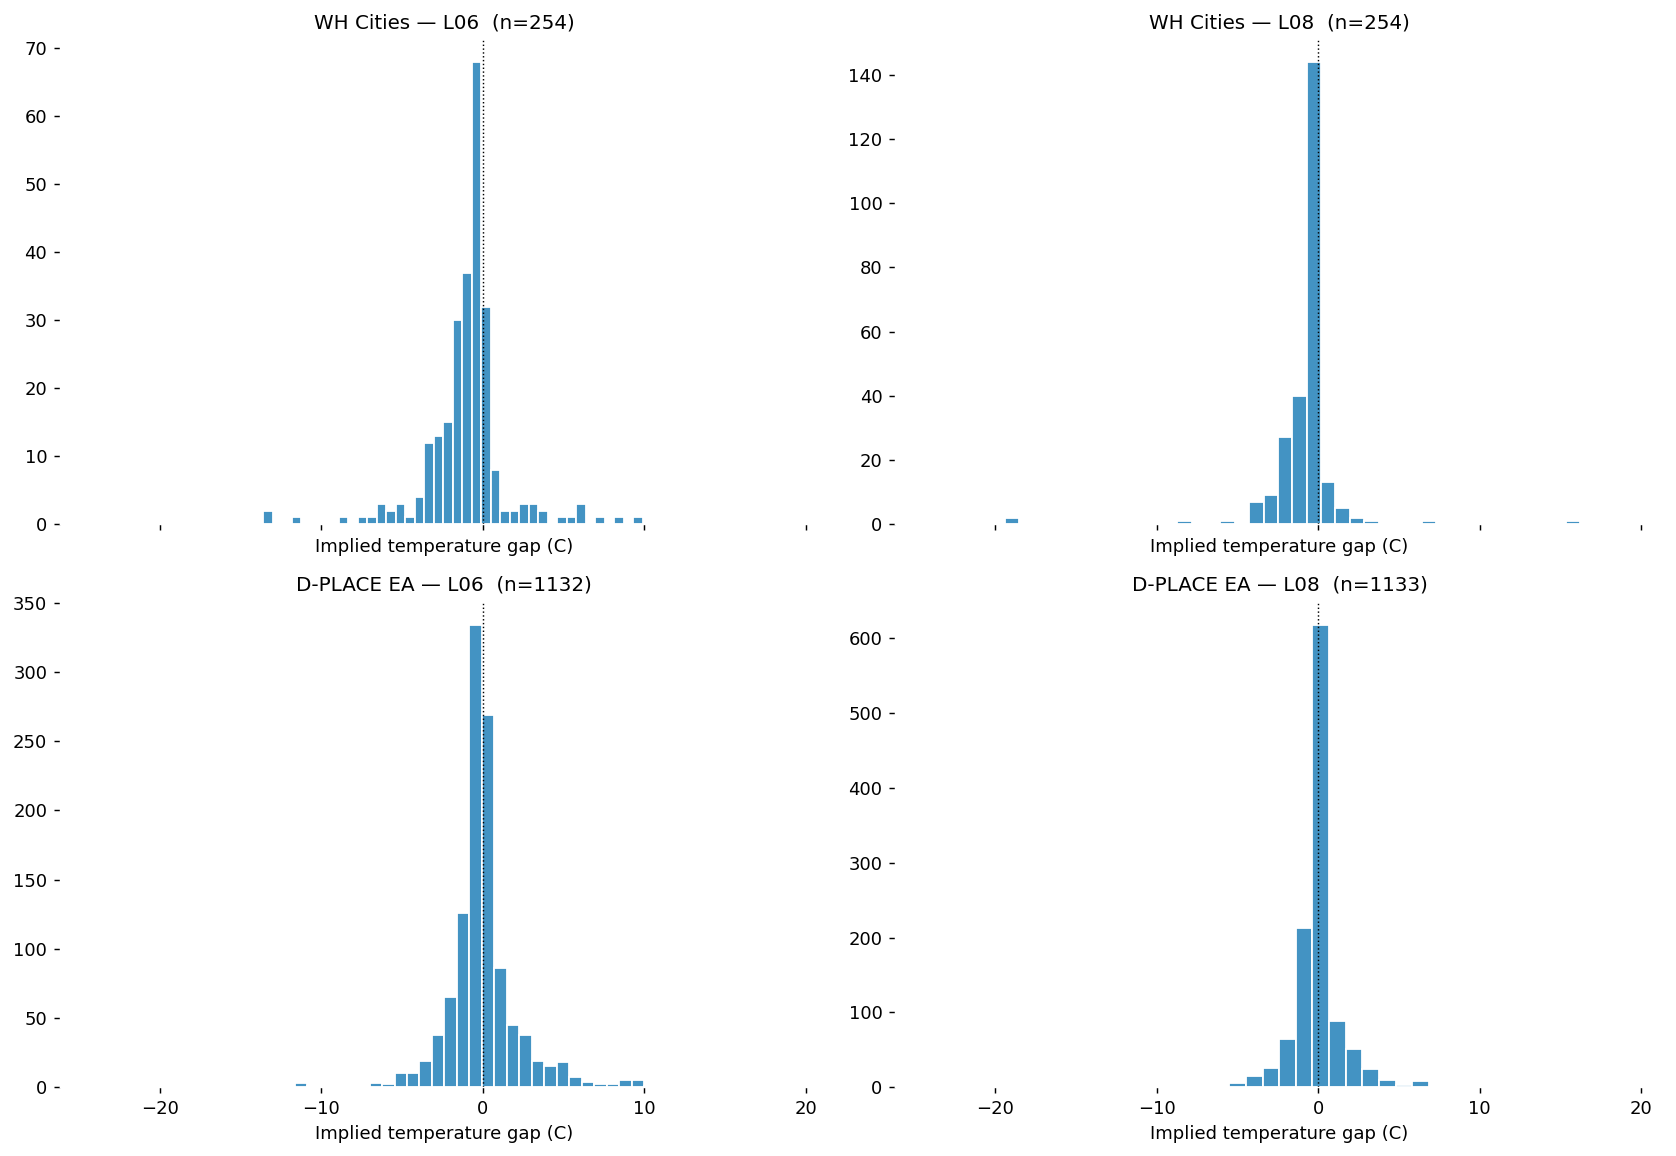

In [16]:
# Cell 16 — Plot: distribution of implied temperature gap, by corpus, L06 vs L08
print("drawing elevation-divergence exposure histograms...")

fig, axes = plt.subplots(2, 2, figsize=(13, 9), sharex=True)
fig.patch.set_facecolor('white')
panels = [('WH Cities', 'l06'), ('WH Cities', 'l08'), ('D-PLACE EA', 'l06'), ('D-PLACE EA', 'l08')]
for ax, (name, level) in zip(axes.flat, panels):
    vals = corpus.loc[corpus['corpus'] == name, f'temp_gap_{level}_c'].dropna()
    ax.hist(vals, bins=40, color='#4393c3', edgecolor='white')
    ax.axvline(0, color='black', lw=0.8, ls=':')
    ax.set_title(f"{name} — {level.upper()}  (n={len(vals)})", color='black', fontsize=11)
    ax.set_xlabel('Implied temperature gap (C)', color='black')
    ax.set_facecolor('white')
    ax.tick_params(colors='black')
fig.tight_layout()
out_path = OUT / 'wo4_part0_elevation_gap_hist.png'
fig.savefig(out_path, facecolor='white', dpi=130, bbox_inches='tight')
plt.close(fig)
display(IPImage(str(out_path)))

## Part 1 — Analogue

Global nearest neighbours in lens space at L08, no exclusions. Top-10 with distances, place
names, and great-circle distance from the query. Place names resolved on-the-fly against
`gaz.whg_gaz` for just the returned basins (no precomputed `hybas_id_l08` column exists yet —
unlike L06 — so this is a per-call spatial join; fine for a handful of basins, would want
precomputing if this pattern gets reused at production scale, per WO7's own rationale for why
`hybas_id_l06` was precomputed in the first place).

In [10]:
# Cell 18 — Part 1: name a set of L08 basins via whg_gaz (on-the-fly spatial join)
import warnings; warnings.filterwarnings("ignore", message="pandas only supports SQLAlchemy")

def name_basins_l08(hybas_ids):
    hybas_ids = [int(h) for h in hybas_ids]
    if not hybas_ids:
        return {}
    id_list = ','.join(str(h) for h in hybas_ids)
    sql = f"""
    SELECT DISTINCT ON (b.hybas_id) b.hybas_id, g.place_name,
           ST_Y(ST_Centroid(b.geom)) AS lat, ST_X(ST_Centroid(b.geom)) AS lon
    FROM basin08 b
    LEFT JOIN gaz.whg_gaz g ON ST_Within(ST_SetSRID(ST_MakePoint(g.lon, g.lat), 4326), b.geom)
    WHERE b.hybas_id IN ({id_list})
    ORDER BY b.hybas_id, g.place_id
    """
    df = pd.read_sql(sql, conn)
    df = df.drop_duplicates('hybas_id')
    return df.set_index('hybas_id').to_dict('index')

print("Basin-naming helper ready (on-the-fly, per-call).")

Basin-naming helper ready (on-the-fly, per-call).


In [11]:
# Cell 19 — Part 1: top-10 analogue @L08 per probe, with distance + great-circle distance + place name
import warnings; warnings.filterwarnings("ignore", message="pandas only supports SQLAlchemy")

part1_results = {}
for name, lat, lon in PROBES:
    qrow = probe_basins[(probe_basins['probe'] == name) & (probe_basins['level'] == 8)]
    qz = query_feat_z(qrow, Z08_MU, Z08_SD)
    nn = top_n_neighbors(df08, Z08_MU, Z08_SD, qz, n=10)
    names = name_basins_l08(nn['hybas_id'].tolist())
    nn = nn.copy()
    nn['place_name'] = nn['hybas_id'].map(lambda h: names.get(int(h), {}).get('place_name'))
    nn['nbr_lat'] = nn['hybas_id'].map(lambda h: names.get(int(h), {}).get('lat'))
    nn['nbr_lon'] = nn['hybas_id'].map(lambda h: names.get(int(h), {}).get('lon'))
    nn['great_circle_km'] = haversine_km(lat, lon, nn['nbr_lat'], nn['nbr_lon'])
    part1_results[name] = nn

print("Part 1 — top-10 analogue @L08, per probe\n")
for name, nn in part1_results.items():
    print(f"  {name}:")
    cols = ['hybas_id', 'dist', 'great_circle_km', 'place_name']
    print(nn[cols].to_string(index=False))
    print()

Part 1 — top-10 analogue @L08, per probe

  Mombasa:
    hybas_id     dist  great_circle_km place_name
1080008720.0 0.250195        24.616711       None
1080008820.0 0.339242        65.895686       None
1080008860.0 0.340216        79.489366    Mwereni
1080008880.0 0.369723        93.611952      Vanga
1080008730.0 0.379858        17.687384       None
1081212420.0 0.411712       118.112722       None
1080008780.0 0.411979        29.500429       None
1080008890.0 0.428282       100.514180       None
1080008640.0 0.429212        46.926334     Kilifi
1080008480.0 0.431597       152.191392       None

  Augsburg:
    hybas_id     dist  great_circle_km    place_name
2080479800.0 0.040248        66.521664      Brandach
2080470590.0 0.041252        55.040235     Steinbach
2080479410.0 0.055830        41.206716  Zankenhausen
2080474060.0 0.075484        56.720480      Grubmühl
2080483630.0 0.082702        89.475277   Sindelsdorf
2080474840.0 0.097362        37.359187       Hoflach
2080477100.0 

In [ ]:
# Cell 20 — Part 1: monthly profile glyph for each probe (query only; 2-harmonic fit overlay)
print("drawing probe monthly profile glyphs...")

def two_harmonic_fit(vals):
    total = vals.sum()
    if total == 0:
        return np.zeros(12)
    a1 = (vals * np.cos(theta1)).sum() / total
    b1 = (vals * np.sin(theta1)).sum() / total
    a2 = (vals * np.cos(theta2)).sum() / total
    b2 = (vals * np.sin(theta2)).sum() / total
    mean = total / 12
    return (mean + total * (a1*np.cos(theta1) + b1*np.sin(theta1)
                          + a2*np.cos(theta2) + b2*np.sin(theta2))).clip(0)

month_labels = ['J','F','M','A','M','J','J','A','S','O','N','D']
x = np.arange(12)

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
fig.patch.set_facecolor('white')
for ax, (name, lat, lon) in zip(axes.flat, PROBES):
    qrow = probe_basins[(probe_basins['probe'] == name) & (probe_basins['level'] == 8)].iloc[0]
    vals = qrow[month_cols].values.astype(float)
    fit = two_harmonic_fit(vals)
    ax.bar(x, vals, color='#6baed6', width=0.65, alpha=0.8)
    ax.plot(x, fit, color='black', lw=1.8, ls='--')
    ax.set_title(f"{name}  {int(qrow['pre_mm_syr'])} mm/yr", fontsize=10, color='black')
    ax.set_xticks(x); ax.set_xticklabels(month_labels, fontsize=8, color='black')
    ax.tick_params(colors='black')
    ax.set_facecolor('white')
for ax in axes.flat[len(PROBES):]:
    ax.axis('off')
fig.tight_layout()
out_path = OUT / 'wo4_part1_probe_glyphs.png'
fig.savefig(out_path, facecolor='white', dpi=130, bbox_inches='tight')
plt.close(fig)
display(IPImage(str(out_path)))

## Part 2 — Analogue net of geography

Same computation, excluding basins within *n* km of the query. Sweep n = 250, 1000, 2500, 5000 km.

In [12]:
# Cell 22 — Part 2: geography-excluded top-5, sweep exclusion radius
import warnings; warnings.filterwarnings("ignore", message="pandas only supports SQLAlchemy")

# Basin centroids needed to compute distance-from-query for exclusion — compute once for all of df08
print("Computing L08 basin centroids (one-time; needed for the geography exclusion)...")
cent_sql = "SELECT hybas_id, ST_Y(ST_Centroid(geom)) AS lat, ST_X(ST_Centroid(geom)) AS lon FROM basin08"
cent08 = pd.read_sql(cent_sql, conn)
df08c = df08.merge(cent08, on='hybas_id', how='left')

RADII_KM = [250, 1000, 2500, 5000]

def top_n_excluding(df, mu, sd, query_feat_z, qlat, qlon, radius_km, n=5):
    Xz = zscore_transform(df, mu, sd)
    valid = ~np.isnan(Xz).any(axis=1)
    d_geo = haversine_km(qlat, qlon, df['lat'].values, df['lon'].values)
    mask = valid & (d_geo > radius_km)
    sub = df[mask].copy()
    Xzsub = Xz[mask]
    dists = np.sqrt(((Xzsub - query_feat_z)**2).sum(axis=1))
    sub['dist'] = dists
    return sub.nsmallest(n, 'dist')

print("Part 2 — top-5 @L08 excluding basins within radius n, per probe\n")
for name, lat, lon in PROBES:
    qrow = probe_basins[(probe_basins['probe'] == name) & (probe_basins['level'] == 8)]
    qz = query_feat_z(qrow, Z08_MU, Z08_SD)
    print(f"  {name}:")
    for radius in RADII_KM:
        nn = top_n_excluding(df08c, Z08_MU, Z08_SD, qz, lat, lon, radius, n=5)
        if nn.empty:
            print(f"    n={radius:>5} km: no basins remain")
            continue
        names = name_basins_l08(nn['hybas_id'].tolist())
        best = nn.iloc[0]
        best_name = names.get(int(best['hybas_id']), {}).get('place_name')
        print(f"    n={radius:>5} km: closest remaining dist={best['dist']:.4f}  "
              f"hybas={int(best['hybas_id'])}  place={best_name}")
    print()

    n= 5000 km: closest remaining dist=0.2844  hybas=5080056550  place=Green Head



## Part 3 — Matched control set

**Locked scope (D-PLACE audit, 2026-07-20): EA-only, 1,291 societies, 1,133 with L08 basin
(87.8%).** Validation case `EA042` (dominant subsistence) — a smoke test, not a finding.
Construction only; do **not** run the actual correspondence test here (out of scope by the WO).

Family crosswalk built fresh here (held during the audit, now needed): the Glottolog family
tree files on disk (`data/dplace/cldf/trees/*.trees`, NEXUS format) have their leaf glottocodes
extracted by regex — no tree-topology parsing needed, just leaf-set membership.

In [17]:
# Cell 24 — Part 3: build glottocode -> family_id crosswalk from the 80 Glottolog family trees
GLOTTOCODE_RE = re.compile(r'([a-z0-9]{4}[1-9][0-9]{3}):')

family_files = sorted(DPLACE_CLDF.glob('trees/*.trees'))
# Glottolog family trees are named by their own top-level glottocode (e.g. atla1278.trees);
# Phlorest study-specific phylogenies (e.g. bouckaert_et_al2012.trees) are a different kind of
# tree (a specific paper's result, not a family classification) — exclude those from the
# family crosswalk by requiring the filename stem itself look like a glottocode.
family_files = [f for f in family_files if re.fullmatch(r'[a-z0-9]{4}[1-9][0-9]{3}', f.stem)]
print(f"{len(family_files)} Glottolog family tree files found")

glottocode_to_family = {}
for f in family_files:
    text = f.read_text()
    leaves = set(GLOTTOCODE_RE.findall(text))
    for g in leaves:
        glottocode_to_family[g] = f.stem

print(f"Crosswalk covers {len(glottocode_to_family):,} distinct glottocodes")

85 Glottolog family tree files found
Crosswalk covers 1,245 distinct glottocodes


In [21]:
# Cell 25 — Part 3: load EA societies (basin-linked, L08) + EA042 + family
#
# Family resolution uses language_level_glottocodes, not glottocode directly. CLDF's own field
# description: "differs for dialects and lists all contained languages for subgroups... can be
# used to match societies to languages in the Glottolog classification trees" — glottocode alone
# can be a dialect-level code that never appears as a tree leaf. Space-separated; try each,
# fall back to glottocode if the field is null.
import warnings; warnings.filterwarnings("ignore", message="pandas only supports SQLAlchemy")

ea_full_sql = """
SELECT s.id, s.name, s.latitude AS lat, s.longitude AS lon,
       s.glottocode, s.language_level_glottocodes,
       b8.hybas_id, {feat_placeholder}
FROM dplace.societies s
JOIN dplace.society_basin sb ON sb.soc_id = s.id AND sb.basin_level = 8
JOIN basin08 b8 ON b8.hybas_id = sb.basin_id
WHERE s.type = 'society' AND s.contribution_id = 'dplace-dataset-ea'
""".replace("{feat_placeholder}", BASIN_COLS.replace("hybas_id, ", ""))

ea3 = pd.read_sql(ea_full_sql, conn)
ea3 = add_harmonic_features(ea3)

def resolve_family(row, family_map):
    candidates = []
    llg = row['language_level_glottocodes']
    if isinstance(llg, str) and llg.strip():
        candidates.extend(llg.split())
    if isinstance(row['glottocode'], str):
        candidates.append(row['glottocode'])
    for code in candidates:
        if code in family_map:
            return family_map[code]
    return None

ea3['family_id'] = ea3.apply(lambda r: resolve_family(r, glottocode_to_family), axis=1)
print(f"{len(ea3)} EA societies with L08 basin; "
      f"{ea3['family_id'].notna().sum()} ({100*ea3['family_id'].notna().mean():.1f}%) resolve to a family "
      f"(via language_level_glottocodes, falling back to glottocode)")

# Exclude data-quality/ambiguous codes, not real subsistence categories — same exclusion list
# app/api/routes.py already uses for EA042 on the /societies route.
ea042_sql = """
SELECT d.soc_id, c.name AS ea042
FROM dplace.data d
JOIN dplace.codes c ON c.id = d.code_id
WHERE d.var_id = 'EA042'
  AND c.name NOT IN ('Missing data', '', 'Missing for at least 1 activity', 'Two or more sources')
"""
ea042 = pd.read_sql(ea042_sql, conn)
ea3 = ea3.merge(ea042, left_on='id', right_on='soc_id', how='left')
print(f"{ea3['ea042'].notna().sum()} of {len(ea3)} have a usable EA042 value "
      f"(excluding data-quality/ambiguous codes)")

1133 EA societies with L08 basin; 1049 (92.6%) resolve to a family (via language_level_glottocodes, falling back to glottocode)
1078 of 1133 have a usable EA042 value (excluding data-quality/ambiguous codes)


In [22]:
# Cell 26 — Part 3: matched control set construction (EA042, cross-family, geographically separated)
import warnings; warnings.filterwarnings("ignore", message="pandas only supports SQLAlchemy")

usable = ea3.dropna(subset=FEAT5 + ['ea042', 'family_id']).reset_index(drop=True)
print(f"{len(usable)} of {len(ea3)} EA societies usable for matching "
      f"(have basin features + EA042 + resolved family)")

# "strict" from climate.precip's own locked thresholds (LENS_REGISTRY, app/db/seasonality.py) —
# calibrated in exactly this z-scored 5D euclidean space, so reused rather than guessed fresh.
LENS_TOL = 0.25
GEO_MIN_KM = 1000  # "large geographic separation"

# Same L08 corpus z-score stats as Parts 1/2 — a society's basin feature vector is just another
# query point in the same climate.precip lens space.
Xz = zscore_transform(usable, Z08_MU, Z08_SD)
lat = usable['lat'].values.astype(float)
lon = usable['lon'].values.astype(float)
n = len(usable)

# Pairwise lens distance (euclidean, z-scored 5D)
diff = Xz[:, None, :] - Xz[None, :, :]
D_lens = np.sqrt((diff**2).sum(axis=2))

# Pairwise great-circle distance
LAT_I, LAT_J = np.meshgrid(lat, lat, indexing='ij')
LON_I, LON_J = np.meshgrid(lon, lon, indexing='ij')
D_geo = haversine_km(LAT_I, LON_I, LAT_J, LON_J)

ea042_arr = usable['ea042'].values
fam_arr = usable['family_id'].values
diff_ea042 = ea042_arr[:, None] != ea042_arr[None, :]
diff_family = fam_arr[:, None] != fam_arr[None, :]

upper = np.triu(np.ones((n, n), dtype=bool), k=1)
candidate_mask = upper & (D_lens < LENS_TOL) & diff_ea042 & diff_family & (D_geo > GEO_MIN_KM)

i_idx, j_idx = np.where(candidate_mask)
print(f"\n{len(i_idx)} matched pairs found "
      f"(lens_dist < {LENS_TOL}, differ on EA042, different family, >{GEO_MIN_KM} km apart)")

balance = pd.DataFrame({
    'society_a': usable['name'].values[i_idx],
    'society_b': usable['name'].values[j_idx],
    'ea042_a': ea042_arr[i_idx],
    'ea042_b': ea042_arr[j_idx],
    'family_a': fam_arr[i_idx],
    'family_b': fam_arr[j_idx],
    'lens_dist': D_lens[i_idx, j_idx],
    'great_circle_km': D_geo[i_idx, j_idx],
}).sort_values('lens_dist')

print("\nBalance table — how comparable are the matched environments (closest 20 pairs):\n")
print(balance.head(20).to_string(index=False))

997 of 1133 EA societies usable for matching (have basin features + EA042 + resolved family)

37 matched pairs found (lens_dist < 0.25, differ on EA042, different family, >1000 km apart)

Balance table — how comparable are the matched environments (closest 20 pairs):

      society_a         society_b               ea042_a               ea042_b family_a family_b  lens_dist  great_circle_km
           Masa              Bisa Intensive agriculture Extensive agriculture afro1255 mand1469   0.092589      1760.229397
  Bororo Fulani             Musgu           Pastoralism Intensive agriculture atla1278 afro1255   0.110686      1110.033423
         Patwin            Tswana             Gathering Extensive agriculture wint1258 atla1278   0.116549     16660.114291
        Nomlaki            Tswana             Gathering Extensive agriculture wint1258 atla1278   0.116549     16660.114291
           Bozo            Kotoko               Fishing Intensive agriculture mand1469 afro1255   0.126389     

## Part 4 — Typological position

Per-probe percentile against the **full L06 population** (per the WO's own text), plus
`pre_modality` (bimodal vs unimodal, via `R_dbl` — the WO2a held-out threshold of 0.30, itself
flagged known-suspect: report distance-to-boundary, not just the label). Bioclimate categorical
position (`zone_name`, `biome`) **is included** — corrected 2026-07-21: an earlier pass here
wrongly concluded no such column existed on `basin06`/`basin08` directly. The raw code lives as
`tbi_cl_smj` on `basin06`/`basin08`; the label lookup (`zone_name`, `biome`, plus `zone_id`,
`biome_id`) is exposed by `v_basin06_persist_rev2`/`v_basin08_persist_rev2` — the same views the
signature build already uses. Joined here by `hybas_id`.

In [23]:
# Cell 28 — Part 4: percentile position + modality distance-to-boundary + bioclimate label, @L06
import warnings; warnings.filterwarnings("ignore", message="pandas only supports SQLAlchemy")

df06['R_dbl'] = np.sqrt(df06['a2']**2 + df06['b2']**2)
MODALITY_THRESH = 0.30  # WO2a held-out test threshold; known-suspect, not recalibrated here

PCTL_VARS = ['pre_mm_syr', 'T_mean', 'T_amp', 'ele_mt_sav', 'R_dbl']

# Bioclimate label lookup — v_basin06_persist_rev2 exposes zone_name/biome via hybas_id,
# same view the signature build uses. Raw code is tbi_cl_smj on basin06 itself.
probe_l06_ids = probe_basins.loc[probe_basins['level'] == 6, 'hybas_id'].astype(int).tolist()
id_list = ','.join(str(h) for h in probe_l06_ids)
biome_sql = f"""
SELECT hybas_id, zone_name, biome
FROM v_basin06_persist_rev2
WHERE hybas_id IN ({id_list})
"""
biome_lookup = pd.read_sql(biome_sql, conn).set_index('hybas_id').to_dict('index')

print("Part 4 — percentile position against full L06 population, per probe\n")
for name, lat, lon in PROBES:
    qrow = probe_basins[(probe_basins['probe'] == name) & (probe_basins['level'] == 6)]
    if qrow.empty:
        continue
    qrow = qrow.iloc[0]
    q_r_dbl = np.sqrt(qrow['a2']**2 + qrow['b2']**2)
    print(f"  {name}:")
    for var in PCTL_VARS:
        qval = q_r_dbl if var == 'R_dbl' else qrow[var]
        pctl = 100 * (df06[var].dropna() < qval).mean()
        print(f"    {var:12s} = {qval:8.3f}   percentile = {pctl:5.1f}")
    label = 'bimodal' if q_r_dbl > MODALITY_THRESH else 'unimodal'
    dist_to_boundary = q_r_dbl - MODALITY_THRESH
    print(f"    pre_modality = {label}   (R_dbl - threshold = {dist_to_boundary:+.3f})")
    b = biome_lookup.get(int(qrow['hybas_id']), {})
    print(f"    bioclimate zone = {b.get('zone_name')}   biome = {b.get('biome')}")
    print()

Part 4 — percentile position against full L06 population, per probe

  Mombasa:
    pre_mm_syr   = 1101.000   percentile =  75.4
    T_mean       =   25.383   percentile =  79.1
    T_amp        =    1.869   percentile =  16.8
    ele_mt_sav   =  115.000   percentile =  18.4
    R_dbl        =    0.341   percentile =  86.0
    pre_modality = bimodal   (R_dbl - threshold = +0.041)
    bioclimate zone = Extremely hot and moist   biome = Tropical & Subtropical Moist Broadleaf Forests

  Augsburg:
    pre_mm_syr   = 1006.000   percentile =  72.5
    T_mean       =    6.208   percentile =  31.4
    T_amp        =    8.927   percentile =  51.2
    ele_mt_sav   =  960.000   percentile =  80.5
    R_dbl        =    0.077   percentile =  27.1
    pre_modality = unimodal   (R_dbl - threshold = -0.223)
    bioclimate zone = Cold and mesic   biome = Temperate Broadleaf & Mixed Forests

  Tbilisi:
    pre_mm_syr   =  762.000   percentile =  63.6
    T_mean       =    5.333   percentile =  30.0
    

## Part 5 — Local anomaly (cheap)

Percentile within *n* km of the query, rather than against the whole globe.

In [24]:
# Cell 30 — Part 5: local (regional) percentile vs global percentile, @L06, radius 1000 km
import warnings; warnings.filterwarnings("ignore", message="pandas only supports SQLAlchemy")

print("Computing L06 basin centroids (one-time)...")
cent06 = pd.read_sql("SELECT hybas_id, ST_Y(ST_Centroid(geom)) AS lat, ST_X(ST_Centroid(geom)) AS lon FROM basin06", conn)
df06c = df06.merge(cent06, on='hybas_id', how='left')

LOCAL_RADIUS_KM = 1000

print(f"Part 5 — local (within {LOCAL_RADIUS_KM} km) vs global percentile, @L06, per probe\n")
for name, lat, lon in PROBES:
    qrow = probe_basins[(probe_basins['probe'] == name) & (probe_basins['level'] == 6)]
    if qrow.empty:
        continue
    qrow = qrow.iloc[0]
    d_geo = haversine_km(lat, lon, df06c['lat'].values, df06c['lon'].values)
    local = df06c[d_geo < LOCAL_RADIUS_KM]
    print(f"  {name}  (n_local={len(local)}):")
    for var in ['pre_mm_syr', 'T_mean']:
        global_pctl = 100 * (df06[var].dropna() < qrow[var]).mean()
        local_pctl = 100 * (local[var].dropna() < qrow[var]).mean() if len(local) else np.nan
        print(f"    {var:12s}  global percentile={global_pctl:5.1f}   local percentile={local_pctl:5.1f}")
    print()

Part 5 — local (within 1000 km) vs global percentile, @L06, per probe

  Mombasa  (n_local=253):
    pre_mm_syr    global percentile= 75.4   local percentile= 77.5
    T_mean        global percentile= 79.1   local percentile= 64.0

  Augsburg  (n_local=280):
    pre_mm_syr    global percentile= 72.5   local percentile= 89.3
    T_mean        global percentile= 31.4   local percentile=  3.6

  Tbilisi  (n_local=344):
    pre_mm_syr    global percentile= 63.6   local percentile= 91.9
    T_mean        global percentile= 30.0   local percentile=  2.6

  Kaifeng  (n_local=343):
    pre_mm_syr    global percentile= 61.2   local percentile= 52.2
    T_mean        global percentile= 45.5   local percentile= 65.0

  Timbuktu  (n_local=415):
    pre_mm_syr    global percentile= 17.0   local percentile= 47.2
    T_mean        global percentile= 98.1   local percentile= 61.9

  George Town  (n_local=121):
    pre_mm_syr    global percentile= 97.4   local percentile= 75.2
    T_mean        global 

## Part 6 — Do they differ?

Overlap between Part 1 (analogue) and Part 2 (analogue net of geography, at the largest swept
radius) result sets, per probe. Part 4 produces no instance list — that absence is itself its
answer.

In [25]:
# Cell 32 — Part 6: Jaccard overlap between Part 1 and Part 2 (radius=5000km) result sets, per probe
print("Part 6 — overlap between Part 1 (analogue) and Part 2 (geography-excluded, 5000km)\n")
for name, lat, lon in PROBES:
    qrow = probe_basins[(probe_basins['probe'] == name) & (probe_basins['level'] == 8)]
    qz = query_feat_z(qrow, Z08_MU, Z08_SD)
    set1 = set(part1_results[name]['hybas_id'].astype(int))
    nn2 = top_n_excluding(df08c, Z08_MU, Z08_SD, qz, lat, lon, 5000, n=10)
    set2 = set(nn2['hybas_id'].astype(int))
    jaccard = len(set1 & set2) / len(set1 | set2) if (set1 | set2) else float('nan')
    print(f"  {name}: Jaccard(top-10 analogue, top-10 @5000km-excluded) = {jaccard:.2f}  "
          f"(intersection={len(set1 & set2)})")

print("\nA low Jaccard value means Part 1's 'nearest neighbours' were mostly the query's own")
print("geographic neighbourhood — i.e. Part 1 alone was reporting autocorrelation, not analogy.")
print("State plainly per probe once run: are these four settings of one instrument, or four instruments?")

Part 6 — overlap between Part 1 (analogue) and Part 2 (geography-excluded, 5000km)

  Mombasa: Jaccard(top-10 analogue, top-10 @5000km-excluded) = 0.00  (intersection=0)
  Augsburg: Jaccard(top-10 analogue, top-10 @5000km-excluded) = 0.00  (intersection=0)
  Tbilisi: Jaccard(top-10 analogue, top-10 @5000km-excluded) = 0.00  (intersection=0)
  Kaifeng: Jaccard(top-10 analogue, top-10 @5000km-excluded) = 0.00  (intersection=0)
  Timbuktu: Jaccard(top-10 analogue, top-10 @5000km-excluded) = 0.00  (intersection=0)
  George Town: Jaccard(top-10 analogue, top-10 @5000km-excluded) = 0.00  (intersection=0)
  Santiago: Jaccard(top-10 analogue, top-10 @5000km-excluded) = 0.25  (intersection=4)

A low Jaccard value means Part 1's 'nearest neighbours' were mostly the query's own
geographic neighbourhood — i.e. Part 1 alone was reporting autocorrelation, not analogy.
State plainly per probe once run: are these four settings of one instrument, or four instruments?
